# **Implementasi Arsitektur Artificial Neural Network (ANN) Backpropagation Berbasis Ekstraksi Ciri Histogram HSV untuk Klasifikasi Multi-Kelas Uang Kertas Rupiah**
### Nama: Nabilah Shamid
### NIM: 09021382328147
### Dosen Pengampu: Assoc, Prof. Julian Supardi, S.Pd., M.T., Ph.D.
### Mata Kuliah: Jaringan Syaraf Tiruan

## Import Packages/Libraries

In [20]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from concurrent.futures import ProcessPoolExecutor, as_completed

# Konfigurasi Dataset
DATA_PATH = Path('/kaggle/input/datasets/anidwiastuti/rupiah-banknotes-dataset/dataset')
CATEGORIES = ['1000', '2000', '5000', '10000', '20000', '50000', '100000']

if DATA_PATH.exists():
    print(f"Environment Ready. Dataset di: {DATA_PATH}")
else:
    print("Dataset tidak ditemukan. Cek kembali path Kaggle.")

Environment Ready. Dataset di: /kaggle/input/datasets/anidwiastuti/rupiah-banknotes-dataset/dataset


## Exploratory Data Analysis (EDA)

--- Memulai Exploratory Data Analysis (EDA) ---
Distribusi Kelas: {'1000': 334, '2000': 344, '5000': 344, '10000': 344, '20000': 344, '50000': 344, '100000': 344}


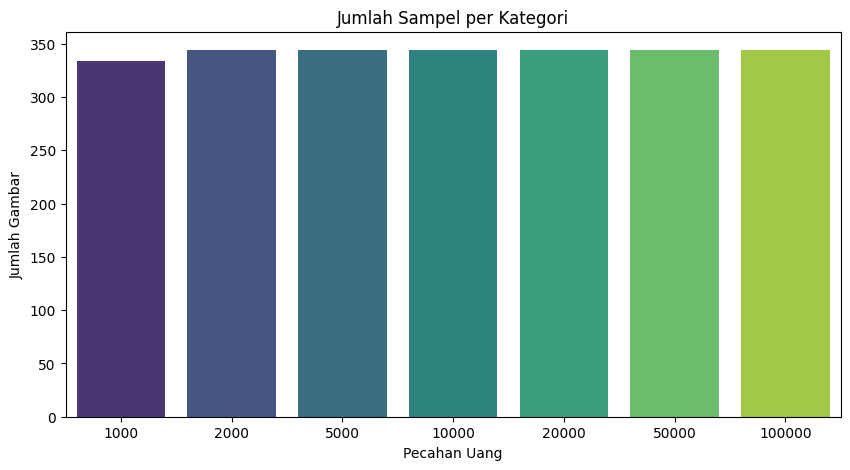

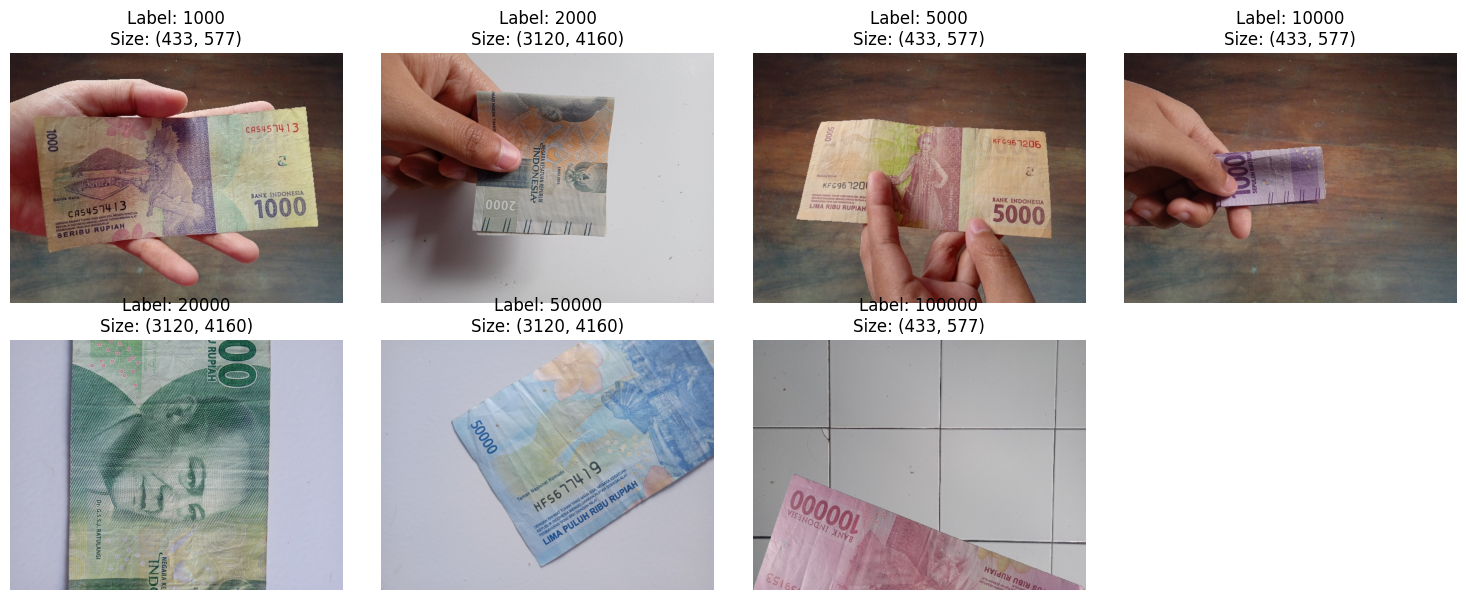

In [3]:
import random

def perform_eda(data_path, categories):
    print("--- Memulai Exploratory Data Analysis (EDA) ---")
    
    # 1. Menghitung Jumlah Data (Class Distribution)
    count_dict = {cat: len(list((data_path / cat).glob('*'))) for cat in categories}
    print(f"Distribusi Kelas: {count_dict}")
    
    # Visualisasi Distribusi
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(count_dict.keys()), 
        y=list(count_dict.values()), 
        hue=list(count_dict.keys()), 
        palette='viridis', 
        legend=False
    )
    plt.title('Jumlah Sampel per Kategori')
    plt.xlabel('Pecahan Uang')
    plt.ylabel('Jumlah Gambar')
    plt.show()
    
    # 2. Visualisasi Contoh Gambar
    plt.figure(figsize=(15, 6))
    
    for i, category in enumerate(categories):
        folder = data_path / category
        sample_images = random.sample(list(folder.glob('*')), 1) 
        
        for j, img_path in enumerate(sample_images):
            plt.subplot(2, 4, i + 1) 
            
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.imshow(img_rgb)
            plt.title(f"Label: {category}\nSize: {img.shape[:2]}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Panggil fungsi EDA
perform_eda(DATA_PATH, CATEGORIES)

## Fungsi Ekstraksi Ciri (Histogram HSV)

In [4]:
def extract_hue_histogram(img_path, bins=32):
    """
    Membaca gambar, mengubah ke HSV, dan mengambil histogram Hue.
    Mengembalikan array 1D berisi nilai fitur yang sudah dinormalisasi.
    """
    # 1. Baca gambar
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    # 2. Konversi BGR ke HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # 3. Hitung Histogram pada channel Hue (0)
    hist = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
    
    # 4. Normalisasi (Scaling awal)
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    
    # 5. Ratakan (flatten) menjadi array 1 dimensi
    return hist.flatten()

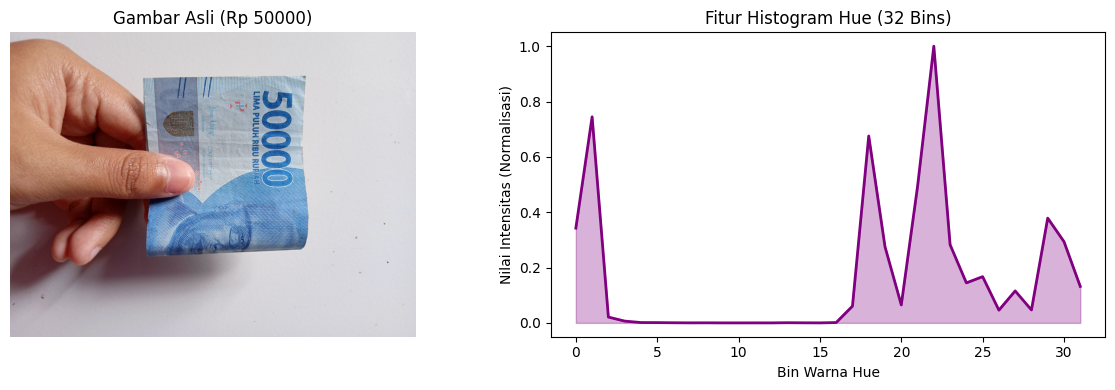

In [6]:
# Ambil satu gambar acak dari dataset (misal dari folder 50000)
sample_cat = '50000'
sample_folder = DATA_PATH / sample_cat
sample_path = random.choice(list(sample_folder.glob('*')))

# Lakukan ekstraksi ciri pada gambar sampel
hist_features = extract_hue_histogram(sample_path)

# Baca gambar asli untuk ditampilkan
img_bgr = cv2.imread(str(sample_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Visualisasi
plt.figure(figsize=(12, 4))

# Plot 1: Gambar Asli
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title(f"Gambar Asli (Rp {sample_cat})")
plt.axis('off')

# Plot 2: Grafik Histogram (Ini yang akan masuk ke JST)
plt.subplot(1, 2, 2)
plt.plot(hist_features, color='purple', linewidth=2)
plt.fill_between(range(len(hist_features)), hist_features, color='purple', alpha=0.3)
plt.title("Fitur Histogram Hue (32 Bins)")
plt.xlabel("Bin Warna Hue")
plt.ylabel("Nilai Intensitas (Normalisasi)")

plt.tight_layout()
plt.show()

## Parallel Data Loading

In [10]:
H_BINS = 32
X_list = []
y_list = []

# 1. Kumpulkan semua path gambar dan index labelnya
image_data = []
for i, category in enumerate(CATEGORIES):
    folder = DATA_PATH / category
    for img_path in folder.glob('*'):
        image_data.append((img_path, i))

print(f"Total gambar yang akan diproses: {len(image_data)}")

# 2. Fungsi pembantu untuk memproses satu data (dibutuhkan untuk mapping paralel)
def process_single_image(data):
    path, label_idx = data
    features = extract_hue_histogram(path, bins=H_BINS)
    return features, label_idx

# 3. Eksekusi Paralel
# Menggunakan ProcessPoolExecutor untuk memanfaatkan multi-core CPU
with ProcessPoolExecutor() as executor:
    # Submit semua tugas ke executor
    futures = {executor.submit(process_single_image, data): data for data in image_data}
    
    # Gunakan tqdm untuk menampilkan progress bar
    for future in tqdm(as_completed(futures), total=len(image_data), desc="Ekstraksi Ciri"):
        features, label_idx = future.result()
        if features is not None:
            X_list.append(features)
            y_list.append(label_idx)


Total gambar yang akan diproses: 2398


Ekstraksi Ciri: 100%|██████████| 2398/2398 [01:01<00:00, 38.96it/s]


## Data Preparation (Scaling & Splitting)

In [11]:
# 1. Konversi List ke Numpy Array dan atur tipe datanya agar ringan
X = np.array(X_list).astype('float32')
y = np.array(y_list)

print("--- Preprocessing Label & Split Data ---")

# 2. One-Hot Encoding Label
num_classes = len(CATEGORIES)
y_one_hot = np.eye(num_classes)[y]

# 3. Train-Test Split (80% Data Latih, 20% Data Uji)
# parameter stratify=y memastikan setiap pecahan uang terbagi rata
X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot, test_size=0.2, random_state=42, stratify=y
)

print(f"Bentuk Input (X_train) : {X_train.shape} -> Siap masuk Input Layer JST ({H_BINS} Neuron)")
print(f"Bentuk Target (y_train): {y_train.shape} -> Siap masuk Output Layer JST ({num_classes} Neuron)")
print(f"Jumlah Data Uji (Test) : {len(X_test)} gambar")

--- Preprocessing Label & Split Data ---
Bentuk Input (X_train) : (1918, 32) -> Siap masuk Input Layer JST (32 Neuron)
Bentuk Target (y_train): (1918, 7) -> Siap masuk Output Layer JST (7 Neuron)
Jumlah Data Uji (Test) : 480 gambar


## Neural Network Architecture & Manual Backpropagation Implementation

In [17]:
class ManualBackprop:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate
        
        # Inisialisasi He untuk kestabilan awal
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        self.loss_history = []
        self.acc_history = []

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, A):
        return (A > 0).astype(float)

    # Fungsi Softmax untuk mengubah output jadi persentase peluang
    def softmax(self, x):
        exps = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

    def train(self, X, y, epochs):
        m = X.shape[0] # Jumlah total data gambar

        for epoch in range(epochs):
            # A. FEED FORWARD
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = self.relu(Z1)
            
            Z2 = np.dot(A1, self.W2) + self.b2
            A2 = self.softmax(Z2) # 
            
            # B. HITUNG ERROR (CROSS ENTROPY)
            epsilon = 1e-15 # Mencegah error log(0)
            loss = -np.sum(y * np.log(A2 + epsilon)) / m
            self.loss_history.append(loss)
            
            # Hitung akurasi
            predictions = np.argmax(A2, axis=1)
            true_labels = np.argmax(y, axis=1)
            accuracy = np.mean(predictions == true_labels)
            self.acc_history.append(accuracy)
            
            # C. BACKPROPAGATION
            dZ2 = A2 - y 
            dW2 = np.dot(A1.T, dZ2) / m
            db2 = np.sum(dZ2, axis=0, keepdims=True) / m
            
            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * self.relu_derivative(A1)
            dW1 = np.dot(X.T, dZ1) / m
            db1 = np.sum(dZ1, axis=0, keepdims=True) / m
            
            # D. UPDATE BOBOT
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            
            if (epoch + 1) % 500 == 0:
                print(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.4f} | Accuracy: {accuracy*100:.2f}%")

    def predict(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        return self.softmax(Z2)

## Training Model & Evaluasi

Epoch  500/3000 | Loss: 0.3944 | Accuracy: 87.02%
Epoch 1000/3000 | Loss: 0.2912 | Accuracy: 90.15%
Epoch 1500/3000 | Loss: 0.2397 | Accuracy: 91.40%
Epoch 2000/3000 | Loss: 0.2084 | Accuracy: 92.81%
Epoch 2500/3000 | Loss: 0.1863 | Accuracy: 93.48%
Epoch 3000/3000 | Loss: 0.1693 | Accuracy: 93.95%


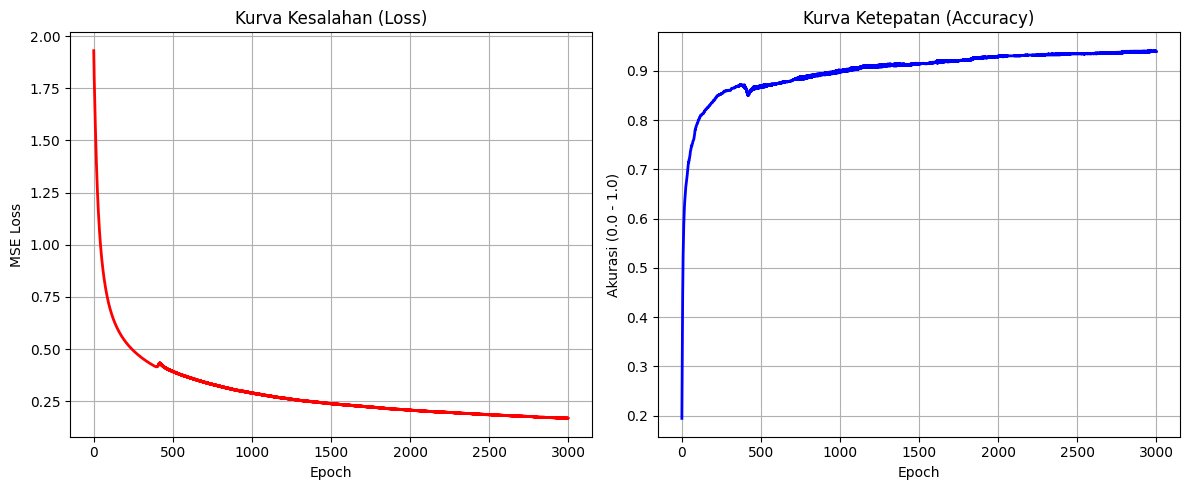

In [18]:
INPUT_NEURON = X_train.shape[1]   
HIDDEN_NEURON = 64                
OUTPUT_NEURON = y_train.shape[1]  


EPOCHS = 3000         
LEARNING_RATE = 0.5   

model = ManualBackprop(INPUT_NEURON, HIDDEN_NEURON, OUTPUT_NEURON, LEARNING_RATE)
model.train(X_train, y_train, epochs=EPOCHS)

# 4. Visualisasi Kurva Pembelajaran (Loss & Accuracy)
plt.figure(figsize=(12, 5))

# Plot 1: Loss (Error)
plt.subplot(1, 2, 1)
plt.plot(model.loss_history, color='red', linewidth=2)
plt.title('Kurva Kesalahan (Loss)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

# Plot 2: Akurasi
plt.subplot(1, 2, 2)
plt.plot(model.acc_history, color='blue', linewidth=2)
plt.title('Kurva Ketepatan (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi (0.0 - 1.0)')
plt.grid(True)

plt.tight_layout()
plt.show()

Akurasi pada Data Uji (Unseen Data): 91.67%



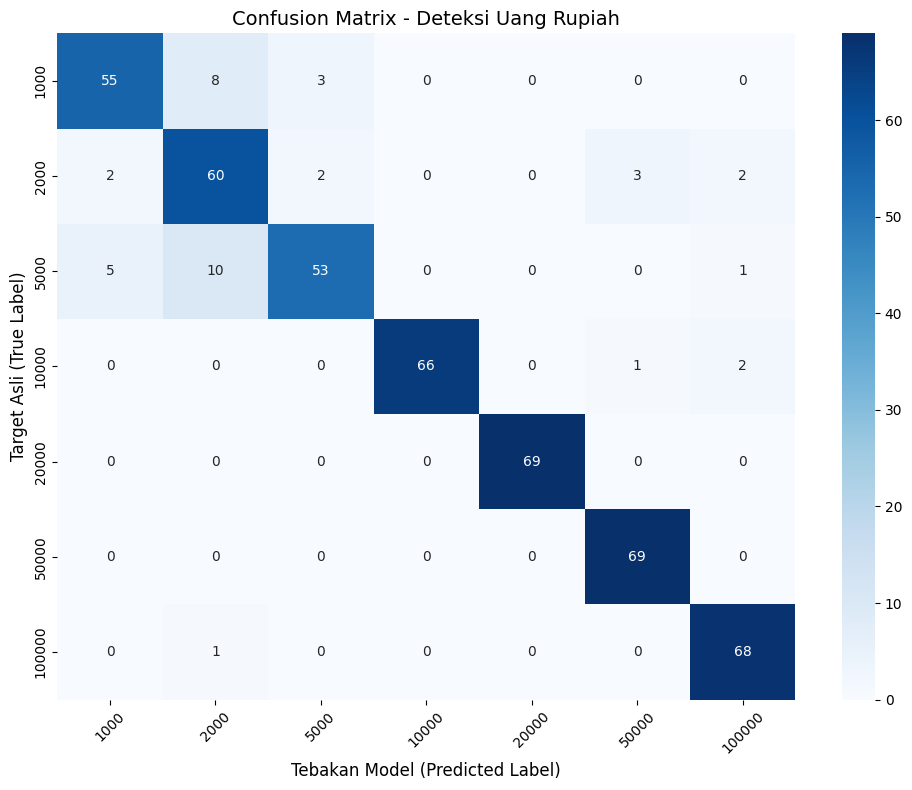


--- Laporan Klasifikasi Lengkap ---
              precision    recall  f1-score   support

        1000       0.89      0.83      0.86        66
        2000       0.76      0.87      0.81        69
        5000       0.91      0.77      0.83        69
       10000       1.00      0.96      0.98        69
       20000       1.00      1.00      1.00        69
       50000       0.95      1.00      0.97        69
      100000       0.93      0.99      0.96        69

    accuracy                           0.92       480
   macro avg       0.92      0.92      0.92       480
weighted avg       0.92      0.92      0.92       480



In [25]:
# 1. Prediksi seluruh data uji (X_test)
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Hitung Akurasi Testing
test_accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Akurasi pada Data Uji (Unseen Data): {test_accuracy * 100:.2f}%\n")

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix - Deteksi Uang Rupiah', fontsize=14)
plt.ylabel('Target Asli (True Label)', fontsize=12)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

# 4. Laporan Performa (Precision, Recall, F1-Score)
print("\n--- Laporan Klasifikasi Lengkap ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=CATEGORIES, zero_division=0))

## Simulasi Uji Coba

Mengambil 3 gambar acak dari dataset untuk dites secara visual...

Target Asli: Rp 5000


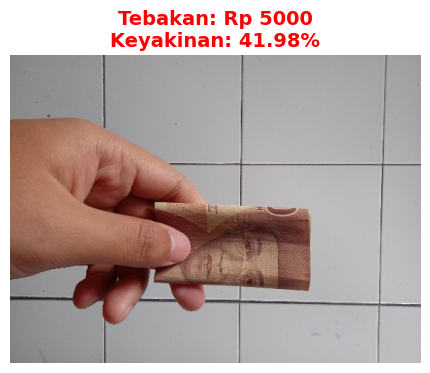

--------------------------------------------------
Target Asli: Rp 50000


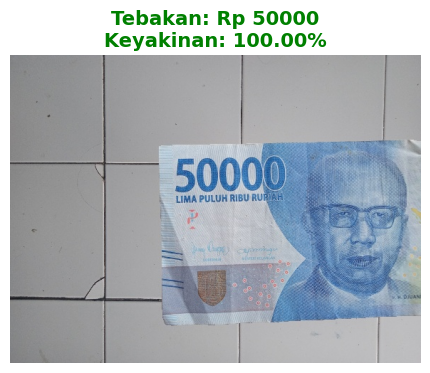

--------------------------------------------------
Target Asli: Rp 1000


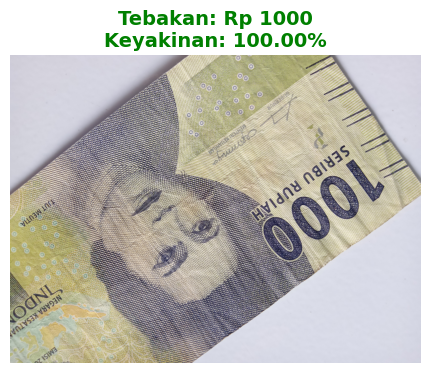

--------------------------------------------------


In [24]:
def predict_and_visualize(img_path):
    # 1. Ekstraksi ciri gambar (menggunakan fungsi dari Cell 1)
    features = extract_hue_histogram(img_path, bins=H_BINS)
    
    if features is None:
        print("Gambar tidak dapat dibaca!")
        return
        
    # 2. Menyesuaikan bentuk array (1 baris, 32 kolom)
    features_input = features.reshape(1, -1)
    
    # 3. Lakukan Prediksi
    probs = model.predict(features_input)[0] # Ambil hasil prediksi pertama
    predicted_idx = np.argmax(probs)
    predicted_label = CATEGORIES[predicted_idx]
    confidence = probs[predicted_idx] * 100
    
    # 4. Baca gambar asli untuk ditampilkan
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 5. Visualisasi Hasil
    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)
    
    # Teks akan berwarna Hijau jika yakin (>80%), Merah jika ragu-ragu
    color = 'green' if confidence >= 80 else 'red'
    
    plt.title(f"Tebakan: Rp {predicted_label}\nKeyakinan: {confidence:.2f}%", 
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.show()


print("Mengambil 3 gambar acak dari dataset untuk dites secara visual...\n")

for _ in range(3):
    # Pilih kategori dan gambar secara acak
    random_category = random.choice(CATEGORIES)
    folder = DATA_PATH / random_category
    random_image_path = random.choice(list(folder.glob('*')))
    
    print(f"Target Asli: Rp {random_category}")
    predict_and_visualize(random_image_path)
    print("-" * 50)

## Ekspor Model Untuk Deployment

In [26]:
import pickle

model_filename = 'backprop_rupiah_model.pkl'

# Membuka/membuat file baru dalam mode 'Write Binary' (wb)
with open(model_filename, 'wb') as file:
    # Membekukan (dump) objek ke dalam file .pkl
    pickle.dump(model, file)

print(f"Model berhasil dibekukan dan disimpan sebagai '{model_filename}'")

Model berhasil dibekukan dan disimpan sebagai 'backprop_rupiah_model.pkl'
